# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Ananya Pal | |
| Member | Saizel Pathania | |


## 2. Mission Title & Research Question

**Title:** *Geopolitical Risk, Exchange Rates, and Financial Market Stability: Evidence from Major Currency Markets and Equity Indices (2021–2026)*

**Research Question:**
*How do changes in geopolitical risk affect exchange rates and major stock-market indices between 2021 and 2026, and what relationships can be observed between geopolitical risk, market volatility, and financial-market performance across the United States, the Eurozone, and the United Kingdom?*

**Why it Matters:**
*Geopolitical tensions influence financial markets by affecting investor expectations, risk perceptions, and capital allocation decisions. Exchange rates and equity markets often react rapidly to increases in geopolitical uncertainty, while market volatility may amplify these effects. Understanding how geopolitical risk is transmitted across currency and stock markets provides insights into market resilience, investor behavior, and the pricing of uncertainty during periods of global instability.*

## 3. Data Source(s):

The analysis combines exchange-rate, stock market, geopolitical risk, and market volatility data from the following sources.

### 1. WRDS Global Exchange Rates (`wrds_g_exrate`)
**Provider:** Compustat Global Daily via WRDS  
**Access Method:** WRDS subscription database  
**URL:** https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/exchange-rates/

**Description:**
- Daily exchange-rate data.
- Focus on EUR, GBP, and USD exchange rates.
- Used to capture currency movements and exchange-rate fluctuations over time.

### 2. Daily Stock Market Indices (Yahoo Finance)
**Provider:** Yahoo Finance  
**Access Method:** Downloaded using the `yfinance` Python package

**Description:**
- Daily closing prices for major stock market indices.
- Indices considered:
  - S&P 500 (United States)
  - DAX (Germany)
  - FTSE 100 (United Kingdom)
- Used to measure stock market performance and investor reactions to geopolitical events.

### 3. Global Geopolitical Risk Index (GPR)
**Provider:** Caldara and Iacoviello  
**Access Method:** Publicly available dataset  
**URL:** https://www.matteoiacoviello.com/gpr_country.htm

**Description:**
- Daily geopolitical risk indicators based on newspaper coverage frequency.
- Measures the intensity of geopolitical tensions and conflicts.
- Serves as the primary explanatory variable in the analysis.

### 4. CBOE Volatility Index (VIX)
**Provider:** Chicago Board Options Exchange (CBOE)  
**Access Method:** Publicly available historical data  
**URL:** https://www.cboe.com/tradable-products/vix/vix-historical-data

**Description:**
- Daily values of the CBOE Volatility Index (VIX).
- Often referred to as the market's "fear index."
- Used as a control variable capturing market uncertainty and investor sentiment.

In [6]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

import pandas as pd
import numpy as np

import yfinance as yf

In [7]:
import wrds 

db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


# 1 Load & Preprocess Data 

'The following output shows the number of currencies available in the WRDS exchange-rate database:'

205

'The following output shows the first 50 available currencies:'

,curd
0,AED
1,AFA
2,AFN
3,ALL
4,AMD
5,ANG
6,AOA
7,AON
8,AOR
9,ARA


'The following output shows the first observations of the raw exchange-rate dataset:'

...

'The following output shows the number of duplicated currency-date combinations:'

np.int64(0)

'The following output shows summary statistics for the numerical variables:'

,datadate,exratd_tousd,exratd_fromusd
count,5964,5964.0,5964.0
mean,2023-09-21 18:49:58.792756480,1.135495,0.892159
min,2021-01-01 00:00:00,0.959911,0.703878
25%,2022-05-12 18:00:00,1.0,0.800448
50%,2023-09-21 12:00:00,1.097631,0.911053
75%,2025-01-31 06:00:00,1.2493,1.0
max,2026-06-12 00:00:00,1.4207,1.041764
std,NaN,0.131883,0.099272


'The following boxplot shows the distribution of exratd_tousd:'

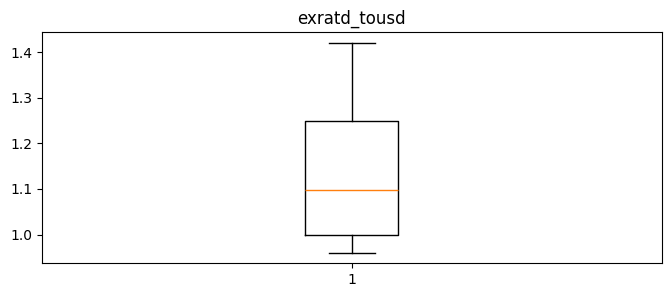

'The following output shows the number of IQR-based outliers in exratd_tousd:'

0

'The following boxplot shows the distribution of exratd_fromusd:'

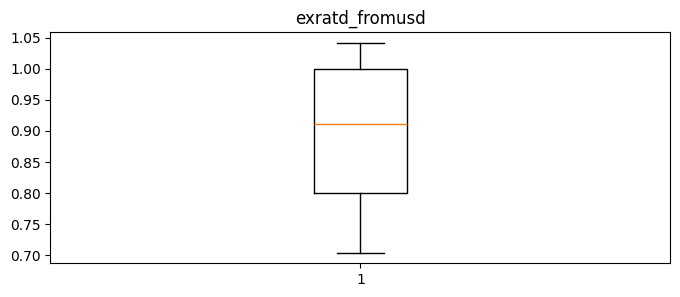

'The following output shows the number of IQR-based outliers in exratd_fromusd:'

0

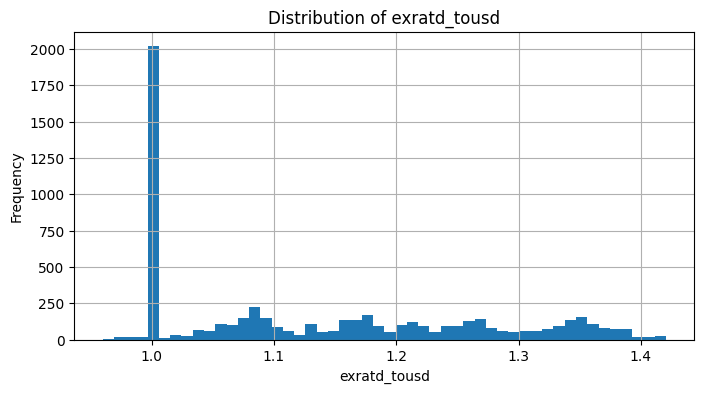

'The following output shows the skewness of exratd_tousd:'

np.float64(0.47752419723364475)

'The following output shows the kurtosis of exratd_tousd:'

np.float64(-1.1624187206259464)

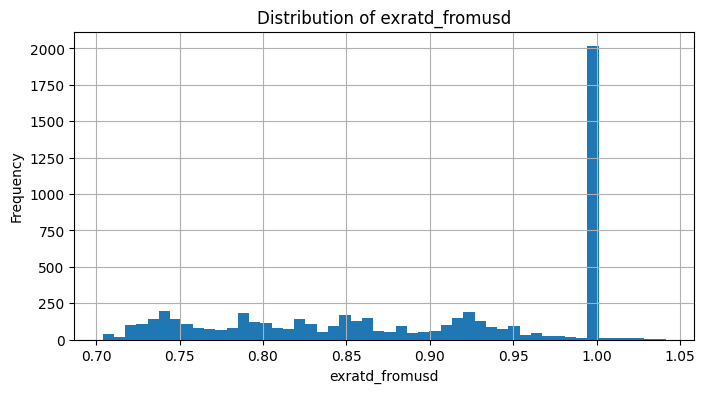

'The following output shows the skewness of exratd_fromusd:'

np.float64(-0.2829102067621029)

'The following output shows the kurtosis of exratd_fromusd:'

np.float64(-1.388662309380339)

'The following output shows the coverage summary by currency:'

,curd,start_date,end_date,observations
0,EUR,2021-01-01,2026-06-12,1988
1,GBP,2021-01-01,2026-06-12,1988
2,USD,2021-01-01,2026-06-12,1988


'The following output shows the first observations of the cleaned exchange-rate dataset:'

,curd,datadate,exratd_tousd,exratd_fromusd
0,EUR,2021-01-01,1.221547,0.818634
1,EUR,2021-01-02,1.221547,0.818634
2,EUR,2021-01-03,1.221547,0.818634
3,EUR,2021-01-04,1.227088,0.814937
4,EUR,2021-01-05,1.227986,0.814341


'The following output confirms the saved Excel file:'

'exchange_rates_eur_gbp_usd.xlsx'

In [8]:
# Available currencies
currencies = db.raw_sql("""
SELECT DISTINCT curd
FROM comp_global_daily.wrds_g_exrate
ORDER BY curd
""")

display("The following output shows the number of currencies available in the WRDS exchange-rate database:")
display(len(currencies))

display("The following output shows the first 50 available currencies:")
display(currencies.head(50))


# Pull exchange-rate data

fx_raw = db.raw_sql("""
SELECT
    curd,
    datadate,
    exratd_tousd,
    exratd_fromusd
FROM comp_global_daily.wrds_g_exrate
WHERE datadate >= '2021-01-01'
ORDER BY curd, datadate
""")

fx_raw["datadate"] = pd.to_datetime(fx_raw["datadate"])

display("The following output shows the first observations of the raw exchange-rate dataset:")
display(fx_raw.head())


# Currency coverage check

availability = db.raw_sql("""
SELECT
    curd,
    MIN(datadate) AS first_date,
    MAX(datadate) AS last_date,
    COUNT(*)      AS n_obs
FROM comp_global_daily.wrds_g_exrate
WHERE curd IN ('EUR','GBP','USD')
GROUP BY curd
ORDER BY curd
""")

display("The following output shows the coverage of the currencies relevant for the project:")
display(availability)


# Retain project currencies

fx = fx_raw[
    fx_raw["curd"].isin(
        ["EUR", "GBP", "USD"]
    )
].copy()

display("The following output shows the dataset after filtering to the selected currencies:")
display(fx.head())


# Data overview

display("The following output shows the dimensions of the dataset:")
display(fx.shape)

display("The following output shows the column names:")
display(pd.DataFrame({"Columns": fx.columns}))

display("The following output shows the data types:")
display(fx.dtypes)

display("The following output shows the first five observations:")
display(fx.head())

display("The following output shows the last five observations:")
display(fx.tail())


# Date coverage

display("The following output shows the date range covered by the dataset:")
display(pd.DataFrame({
    "Start Date": [fx["datadate"].min()],
    "End Date": [fx["datadate"].max()]
}))

display("The following output shows the number of unique dates:")
display(fx["datadate"].nunique())


# Missing values

na_count = fx.isnull().sum()

display("The following output shows the number of missing values per column:")
display(na_count)

na_percent = (
    fx.isnull().sum()
    / len(fx)
    * 100
).round(2)

display("The following output shows the percentage of missing values per column:")
display(na_percent)


# Duplicate checks

display("The following output shows the number of duplicated rows:")
display(fx.duplicated().sum())

display("The following output shows the number of duplicated currency-date combinations:")
display(
    fx.duplicated(
        subset=["curd", "datadate"]
    ).sum()
)


# Numerical summary

display("The following output shows summary statistics for the numerical variables:")
display(fx.describe())


# Outlier analysis

numeric_cols = [
    "exratd_tousd",
    "exratd_fromusd"
]

for col in numeric_cols:

    display(f"The following boxplot shows the distribution of {col}:")

    plt.figure(figsize=(8, 3))
    plt.boxplot(fx[col].dropna())
    plt.title(col)
    plt.show()

    Q1 = fx[col].quantile(0.25)
    Q3 = fx[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = fx[
        (fx[col] < lower) |
        (fx[col] > upper)
    ]

    display(f"The following output shows the number of IQR-based outliers in {col}:")
    display(len(outliers))


# Distribution analysis

for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    fx[col].hist(
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

    display(f"The following output shows the skewness of {col}:")
    display(fx[col].skew())

    display(f"The following output shows the kurtosis of {col}:")
    display(fx[col].kurt())


# Coverage summary by currency

coverage_summary = (
    fx.groupby("curd")
      .agg(
          start_date=("datadate", "min"),
          end_date=("datadate", "max"),
          observations=("datadate", "count")
      )
      .reset_index()
)

display("The following output shows the coverage summary by currency:")
display(coverage_summary)


# Create cleaned dataframe

fx_clean = (
    fx.sort_values(
        ["curd", "datadate"]
    )
    .reset_index(drop=True)
)

display("The following output shows the first observations of the cleaned exchange-rate dataset:")
display(fx_clean.head())


# Save dataset

output_file = "exchange_rates_eur_gbp_usd.xlsx"

fx_clean.to_excel(
    output_file,
    index=False
)

display("The following output confirms the saved Excel file:")
display(output_file)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


'The following output shows the dimensions of the merged index dataset:'

(1402, 4)

'The following output shows the available columns:'

,Column
0,date
1,SP500
2,DAX
3,FTSE


...

np.int64(0)

'The following output shows the number of duplicated dates:'

np.int64(0)

'The following output shows summary statistics for the index variables:'

,date,SP500,DAX,FTSE
count,1402,1362.000000,1382.000000,1368.000000
mean,2023-09-18 03:02:49.472182784,5026.964780,17816.119635,8009.138161
min,2021-01-04 00:00:00,3577.030029,11975.549805,6407.500000
25%,2022-05-11 06:00:00,4169.714966,15147.660156,7317.875000
50%,2023-09-16 12:00:00,4584.114990,15992.555176,7661.750000
75%,2025-01-26 06:00:00,5858.382568,20624.960449,8415.599854
max,2026-06-05 00:00:00,7609.779785,25420.660156,10910.599609
std,NaN,1034.659092,3816.435419,992.571891


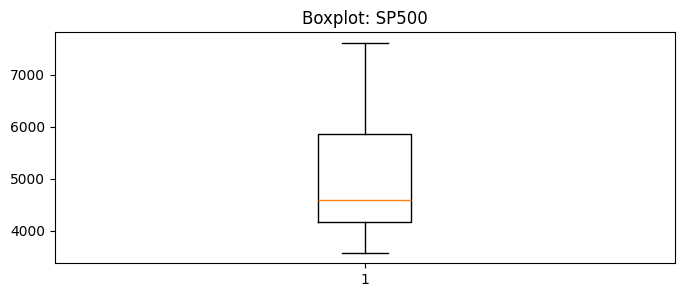

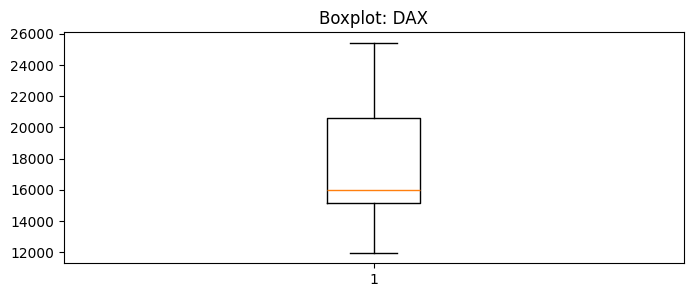

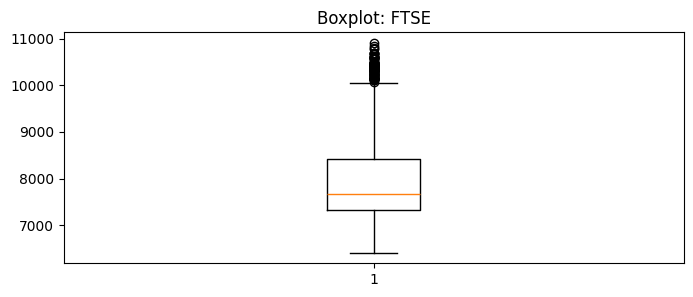

'The following output shows the number of IQR-based outliers in each index:'

,Variable,Outliers
0,SP500,0
1,DAX,0
2,FTSE,98


'The following output shows skewness and kurtosis of the index variables:'

,Variable,Skewness,Kurtosis
0,SP500,0.654066,-0.822815
1,DAX,0.660946,-0.965705
2,FTSE,1.052907,0.340594


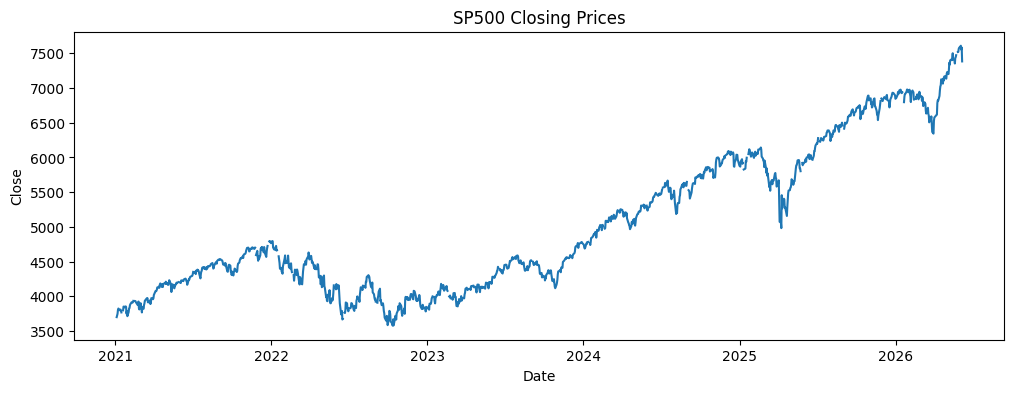

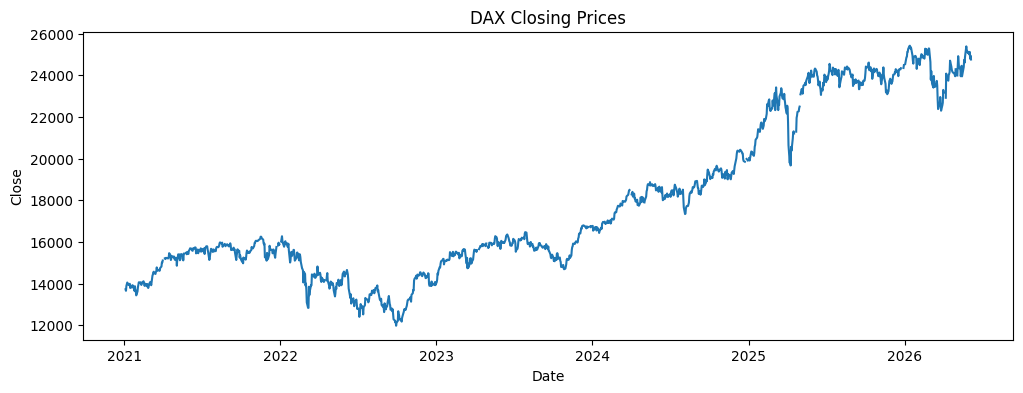

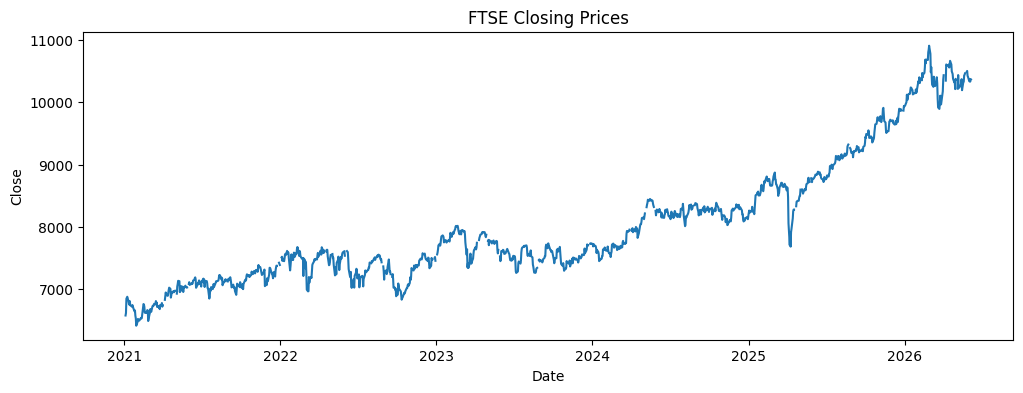

'The following output shows the first observations of the cleaned dataset:'

,date,SP500,DAX,FTSE
0,2021-01-04,3700.649902,13726.740234,6571.899902
1,2021-01-05,3726.860107,13651.219727,6612.299805
2,2021-01-06,3748.139893,13891.969727,6841.899902
3,2021-01-07,3803.790039,13968.240234,6857.000000
4,2021-01-08,3824.679932,14049.530273,6873.299805


'The following output confirms the saved Excel file:'

'indices_clean.xlsx'

In [9]:
# Download daily index data

sp500 = yf.download("^GSPC", start="2021-01-01", end="2026-06-06")
dax   = yf.download("^GDAXI", start="2021-01-01", end="2026-06-06")
ftse  = yf.download("^FTSE", start="2021-01-01", end="2026-06-06")


# Retain only closing prices

sp500 = sp500[["Close"]].reset_index()
dax   = dax[["Close"]].reset_index()
ftse  = ftse[["Close"]].reset_index()


# Rename columns

sp500.columns = ["date", "SP500"]
dax.columns   = ["date", "DAX"]
ftse.columns  = ["date", "FTSE"]


# Merge indices into a single dataframe

indices = (
    sp500
    .merge(dax, on="date", how="outer")
    .merge(ftse, on="date", how="outer")
)

indices["date"] = pd.to_datetime(indices["date"])


# Basic dataset overview

display("The following output shows the dimensions of the merged index dataset:")
display(indices.shape)

display("The following output shows the available columns:")
display(pd.DataFrame({"Column": indices.columns}))

display("The following output shows the data types:")
display(indices.dtypes)

display("The following output shows the first five observations:")
display(indices.head())


# Date coverage

display("The following output shows the date range covered by the dataset:")

display(
    pd.DataFrame({
        "Start Date": [indices["date"].min()],
        "End Date": [indices["date"].max()],
        "Unique Dates": [indices["date"].nunique()]
    })
)


# Missing values

na_count = indices.isnull().sum()

display("The following output shows the number of missing values per column:")
display(na_count)

na_percent = (
    indices.isnull().sum()
    / len(indices)
    * 100
).round(2)

display("The following output shows the percentage of missing values per column:")
display(na_percent)


# Duplicate checks

display("The following output shows the number of duplicated rows:")
display(indices.duplicated().sum())

display("The following output shows the number of duplicated dates:")
display(indices["date"].duplicated().sum())


# Summary statistics

display("The following output shows summary statistics for the index variables:")
display(indices.describe())


# Boxplots

numeric_cols = ["SP500", "DAX", "FTSE"]

for col in numeric_cols:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        indices[col].dropna()
    )

    plt.title(f"Boxplot: {col}")

    plt.show()


# Outlier analysis using the IQR rule

outlier_summary = []

for col in numeric_cols:

    Q1 = indices[col].quantile(0.25)
    Q3 = indices[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (
            indices[col] < lower
        ) |
        (
            indices[col] > upper
        )
    ).sum()

    outlier_summary.append({
        "Variable": col,
        "Outliers": n_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)

display("The following output shows the number of IQR-based outliers in each index:")
display(outlier_summary)


# Distribution diagnostics

distribution_summary = pd.DataFrame({
    "Variable": numeric_cols,
    "Skewness": [
        indices[col].skew()
        for col in numeric_cols
    ],
    "Kurtosis": [
        indices[col].kurt()
        for col in numeric_cols
    ]
})

display("The following output shows skewness and kurtosis of the index variables:")
display(distribution_summary)


# Time-series plots

for col in numeric_cols:

    plt.figure(figsize=(12, 4))

    plt.plot(
        indices["date"],
        indices[col]
    )

    plt.title(f"{col} Closing Prices")
    plt.xlabel("Date")
    plt.ylabel("Close")

    plt.show()


# Create final cleaned dataframe

indices_clean = (
    indices
    .sort_values("date")
    .drop_duplicates()
    .reset_index(drop=True)
)

display("The following output shows the first observations of the cleaned dataset:")
display(indices_clean.head())


# Save processed dataframe

output_file = "indices_clean.xlsx"

indices_clean.to_excel(
    output_file,
    index=False
)

display("The following output confirms the saved Excel file:")
display(output_file)

'Head:'

,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date,GPRD_MA30,GPRD_MA7,event,var_name,var_label
0,19850101,216,230.039429,275.197601,153.027985,1985-01-01,230.039429,230.039429,NaN,DAY,DAY
1,19850102,315,115.676971,146.772064,87.444572,1985-01-02,172.858200,172.858200,NaN,N10D,"Number of articles (10 recent newspapers, 1985-)"
2,19850103,374,97.428459,158.937653,29.459934,1985-01-03,147.714951,147.714951,NaN,GPRD,Daily GPR (Index: 1985:2019=100)
3,19850104,421,157.366638,156.882248,157.026352,1985-01-04,150.127869,150.127869,NaN,GPRD_ACT,Daily GPR Acts (Index: 1985:2019=100)
4,19850105,285,81.361313,92.698143,77.319405,1985-01-05,136.374557,136.374557,NaN,GPRD_THREAT,Daily GPR Threats (Index: 1985:2019=100)


'Filtered GPR dataset: '

,date,GPRD
13149,2021-01-01,65.272270
13150,2021-01-02,39.435329
13151,2021-01-03,19.037745
13152,2021-01-04,99.327362
13153,2021-01-05,121.851952


'Start date:'

...

date    0
GPRD    0
dtype: int64

'Duplicate dates:'

np.int64(0)

'Missing dates:'

0

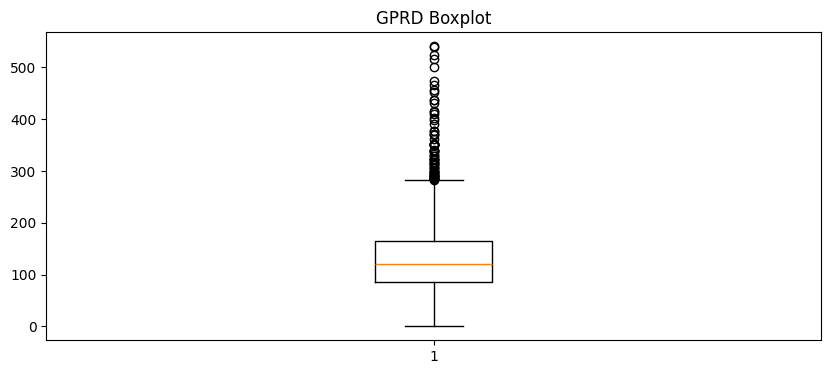

Number of outliers: 73


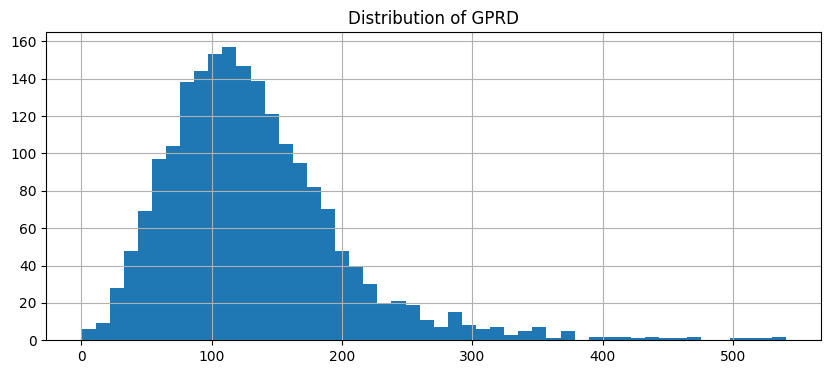

Skewness: 1.5596205174169901
Kurtosis: 4.621476263192783


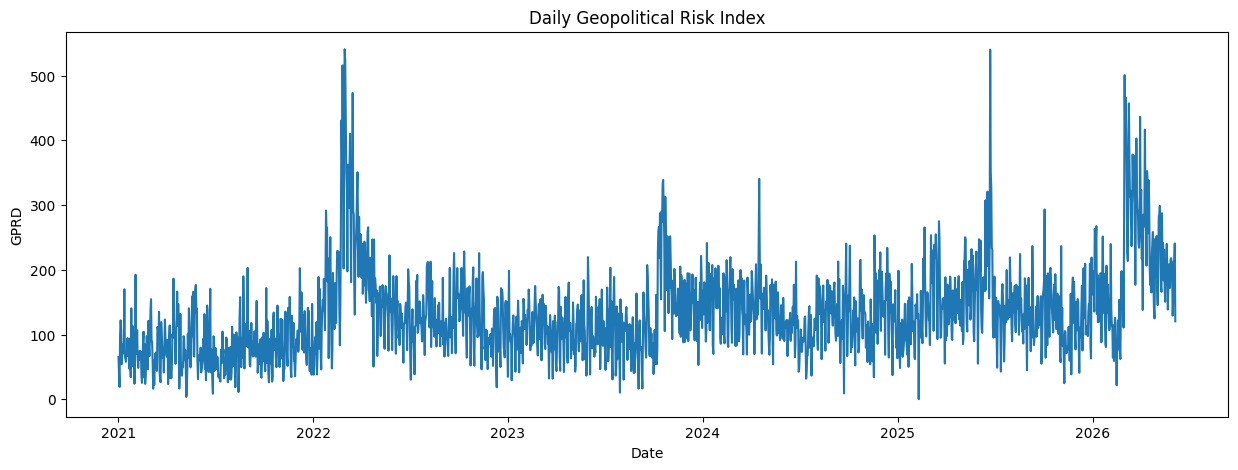

ADF Statistic: -4.037322546946021
p-value: 0.0012272069186486244


,Metric,Value
0,Rows,1982
1,Date Range Start,2021-01-01 00:00:00
2,Date Range End,2026-06-05 00:00:00
3,Missing Values,0
4,Duplicate Rows,0
5,Duplicate Dates,0


In [10]:
# Geopolitical Risk Index (GPR)

# Load data
data = pd.read_excel(Path.cwd() / "data_gpr_daily_recent.xls")
display("Head:", data.head())

# Store the last two columns as metadata
info = data.iloc[:, -2:].copy()

# Retain only the columns required for analysis
gpr = data[["date", "GPRD"]].copy()

# Ensure date is datetime
gpr["date"] = pd.to_datetime(gpr["date"])

# Filter years 2021-2026 (inclusive)
gpr = gpr[(gpr["date"] >= "2021-01-01") & (gpr["date"] <= "2026-06-05")]

# Inspect head of filtered data
display("Filtered GPR dataset: ", gpr.head())

# Data description
display("Start date:", gpr["date"].min())
display("End date:", gpr["date"].max())

display("Unique dates:", gpr["date"].nunique())
display("Total rows:", len(gpr))

# Missing values check
na_count = gpr.isna().sum()
display("Missing values: ",na_count)

# Checking for existence of duplicate dates
duplicate_dates = gpr["date"].duplicated().sum()
display("Duplicate dates:", duplicate_dates)

# Checking for missing dates
full_dates = pd.date_range(
    start=gpr["date"].min(),
    end=gpr["date"].max(),
    freq="D"
)
missing_dates = full_dates.difference(gpr["date"])
display("Missing dates:", len(missing_dates))

# Outlier detection 

plt.figure(figsize=(10,4))
plt.boxplot(gpr["GPRD"])
plt.title("GPRD Boxplot")
plt.show()

# IQR Method
Q1 = gpr["GPRD"].quantile(0.25)
Q3 = gpr["GPRD"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = gpr[
    (gpr["GPRD"] < lower) |
    (gpr["GPRD"] > upper)
]

print("Number of outliers:", len(outliers))

# Distribution analysis 
gpr["GPRD"].hist(
    bins=50,
    figsize=(10,4)
)

plt.title("Distribution of GPRD")
plt.show()

# Skewness
print(
    "Skewness:",
    gpr["GPRD"].skew()
)

print(
    "Kurtosis:",
    gpr["GPRD"].kurtosis()
)

# Time-series visualization

plt.figure(figsize=(15,5))

plt.plot(
    gpr["date"],
    gpr["GPRD"]
)

plt.title("Daily Geopolitical Risk Index")
plt.xlabel("Date")
plt.ylabel("GPRD")

plt.show()

# Stationarity check

result = adfuller(gpr["GPRD"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Project summary table
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Date Range Start",
        "Date Range End",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Dates"
    ],
    "Value": [
        len(gpr),
        gpr["date"].min(),
        gpr["date"].max(),
        gpr.isna().sum().sum(),
        gpr.duplicated().sum(),
        gpr["date"].duplicated().sum()
    ]
})

summary

'Head:'

,DATE,OPEN,HIGH,LOW,CLOSE
0,01/02/1990,17.24,17.24,17.24,17.24
1,01/03/1990,18.19,18.19,18.19,18.19


'Update datetime format:'

,DATE,OPEN,HIGH,LOW,CLOSE
0,1990-01-02,17.24,17.24,17.24,17.24
1,1990-01-03,18.19,18.19,18.19,18.19


'Filtered dataset:'

...

date    0
VIX     0
dtype: int64

'Duplicate dates: '

np.int64(0)

'Dates for which data is missing (including weekends, market holidays):'

587

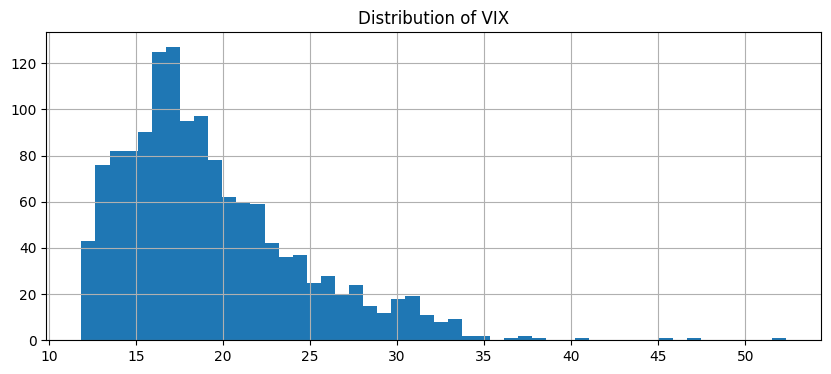

Outliers: 43


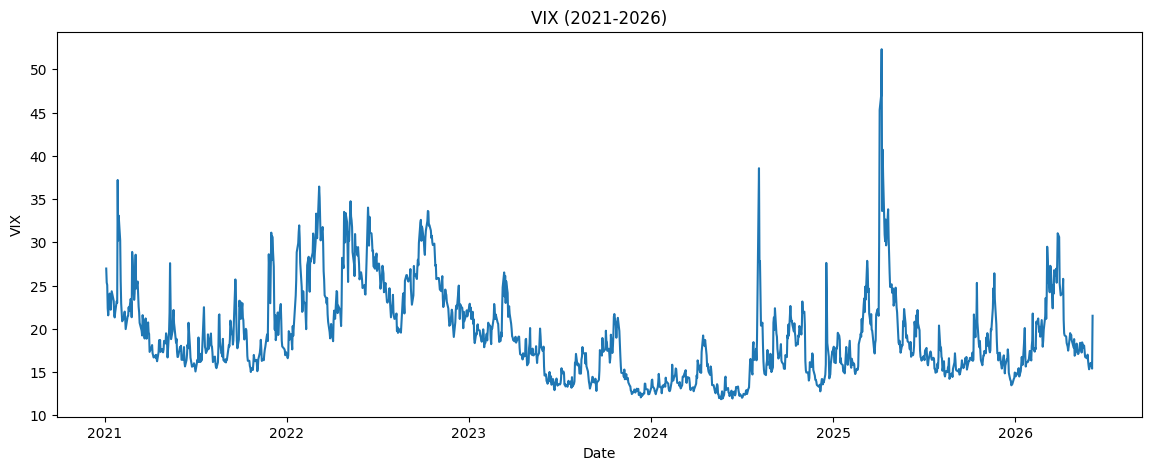

ADF Statistic: -5.573145383395565
p-value: 1.4520816953858902e-06


,Metric,Value
0,Rows,1392
1,Start Date,2021-01-04 00:00:00
2,End Date,2026-06-05 00:00:00
3,Missing Values,0
4,Duplicate Dates,0


In [11]:
# VIX
# Load data
vix_raw = pd.read_csv(Path.cwd() / "VIX_history.csv")
display("Head:", vix_raw.head(2))

# Convert to datetime
vix_raw["DATE"] = pd.to_datetime(vix_raw["DATE"], format="%m/%d/%Y")
display("Update datetime format:", vix_raw.head(2))

# Filter to retain the dates required for analysis
vix = vix_raw.copy()

vix = vix[(vix["DATE"] >= "2021-01-01") & (vix["DATE"] <= "2026-06-05")]

# Retain the closing price only, drop other columns
vix = vix[["DATE", "CLOSE"]]

# Rename the columns 
vix = vix.rename(
    columns={
        "DATE": "date",
        "CLOSE": "VIX"
    }
)

# Briefly view the filtered dataset
display("Filtered dataset:", vix.head(2))

# Get an overview of the datase
display("Shape of the filtered dataset: ", vix.shape)
display("Shape of the filtered dataset: ", vix.dtypes)
display("Describe the data:", vix.describe())

# Missing values 
display("Missing values: ", vix.isna().sum())

# Duplicate dates
display("Duplicate dates: ", vix["date"].duplicated().sum())

# Sort values
vix[vix["date"].duplicated(keep=False)].sort_values("date")

# Missing days
full_dates = pd.date_range(
    start=vix["date"].min(),
    end=vix["date"].max(),
    freq="D")

missing_dates = full_dates.difference(vix["date"])

display("Dates for which data is missing (including weekends, market holidays):",len(missing_dates))

# Distribution
vix["VIX"].hist(
    bins=50,
    figsize=(10,4)
)

plt.title("Distribution of VIX")
plt.show()

# Outlier detection
Q1 = vix["VIX"].quantile(0.25)
Q3 = vix["VIX"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = vix[
    (vix["VIX"] < lower) |
    (vix["VIX"] > upper)
]

print("Outliers:", len(outliers))

# Time series plot

plt.figure(figsize=(14,5))

plt.plot(
    vix["date"],
    vix["VIX"]
)

plt.title("VIX (2021-2026)")
plt.xlabel("Date")
plt.ylabel("VIX")

plt.show()

# Stationarity check

result = adfuller(vix["VIX"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Summary
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Start Date",
        "End Date",
        "Missing Values",
        "Duplicate Dates"
    ],
    "Value": [
        len(vix),
        vix["date"].min(),
        vix["date"].max(),
        vix.isna().sum().sum(),
        vix["date"].duplicated().sum()
    ]
})

summary

## 4. Planned Methods

1. Treatment Variable 
The primary treatment variable is the Daily Geopolitical Risk Index (GPRD) from Caldara and Iacoviello. The index is constructed from newspaper coverage related to geopolitical tensions, military conflicts, terrorism, and international crises. Higher values indicate greater geopolitical uncertainty and conflict intensity. Throughout the project, geopolitical conflict is operationalized and measured using the GPRD index.
2. The VIX is included as a control variable because market-wide uncertainty may influence exchange rates and stock-market returns independently of geopolitical risk.

### 4a. Causal Inference

* [x] **Causal graph / DAG (DoWhy)**
* [x] **Backdoor adjustment**
* [ ] Instrumental variable
* [ ] Propensity score stratification
* [ ] Other: ___

**Justification:**

A Directed Acyclic Graph (DAG) will be constructed to represent the relationships between geopolitical risk (GPR), market volatility (VIX), exchange-rate movements, and stock-market returns. The DAG will be used to identify potential confounding variables and justify adjustment strategies. Backdoor adjustment will then be applied to estimate the effect of geopolitical risk on exchange rates and stock-market returns while controlling for market-wide uncertainty captured by the VIX.

---

### 4b. Supervised Learning

* [x] **Linear / Ridge / Lasso regression**
* [ ] Logistic regression
* [ ] k-Nearest Neighbors
* [ ] Support Vector Machine
* [x] **Decision Tree / Random Forest**
* [ ] Neural network (regression or classification)
* [ ] Other: ___

**Justification:**

Linear, Ridge, and Lasso regression models will be used to quantify and interpret the relationship between geopolitical risk, market volatility, and financial-market outcomes. Random Forest models will serve as nonlinear benchmarks capable of capturing interaction effects and complex relationships among geopolitical risk, volatility, exchange-rate movements, and stock-market returns. Predictive performance across models will be compared to evaluate whether nonlinear approaches provide additional explanatory power.

---

### 4c. Unsupervised Learning / Generative Models

* [x] **K-Means clustering**
* [x] **Hierarchical clustering**
* [ ] Variational autoencoder
* [ ] GAN
* [ ] Other: ___

**Justification:**

Clustering techniques will be used to identify distinct market regimes based on geopolitical risk, market volatility, exchange-rate movements, and stock-market returns. K-Means clustering will be used to partition observations into groups representing stable, elevated-risk, and crisis periods, while hierarchical clustering will provide an interpretable view of similarities among time periods and market conditions. These methods will help reveal whether periods of heightened geopolitical risk exhibit common financial-market characteristics.

## 5. Evaluation Strategy

The impact of geopolitical risk on financial markets will be estimated using regression-based treatment-effect models. The main explanatory variable is the Geopolitical Risk Index (GPR), while the outcome variables are exchange-rate returns and stock-market returns.

For each outcome variable, we estimate models of the following form:

$$
Y_t = \alpha + \beta GPR_t + \gamma X_t + \varepsilon_t
$$

where:

- $Y_t$: financial market outcome (e.g., exchange-rate returns or stock-market returns)
- $GPR_t$: geopolitical risk measure
- $X_t$: vector of control variables
- $\alpha$: intercept term
- $\beta$: estimated effect of geopolitical risk
- $\gamma$: coefficient vector for the control variables
- $\varepsilon_t$: error term

The coefficient of interest is **$\beta$**, which measures the effect of geopolitical risk on the financial-market outcome, holding all control variables constant. Therefore, the estimated treatment effect is obtained from the coefficient on the GPR variable, not from the intercept.

For example, if the dependent variable is S&P 500 returns and the coefficient on GPR is negative, this would suggest that higher geopolitical risk is associated with lower stock-market returns. Similarly, if the dependent variable is EUR/USD or GBP/USD returns, the GPR coefficient indicates whether geopolitical risk is associated with currency appreciation or depreciation.

To make the interpretation more meaningful, the analysis may also use changes in GPR or standardized GPR values. In that case, the coefficient can be interpreted as the effect of a one-standard-deviation increase in geopolitical risk on exchange-rate or stock-market returns.

### How will you know if your mission succeeded?

#### Evaluation Metrics

**Causal Inference**

* Estimated treatment effects of geopolitical risk on exchange-rate returns and stock-market returns.
* Robustness checks using placebo refuters and random common-cause refuters available in DoWhy.
* Sensitivity analysis to evaluate the stability of causal estimates under potential unobserved confounding.

**Supervised Learning**

* Root Mean Squared Error (RMSE)
* Mean Absolute Error (MAE)
* Coefficient of Determination (R²)

These metrics will be used to evaluate how accurately geopolitical risk and market volatility explain or predict financial-market outcomes.

**Unsupervised Learning**

* Silhouette Score
* Davies–Bouldin Index

These metrics will assess cluster quality and separation between identified market regimes.

---

#### Validation of Causal Claims

Causal estimates obtained through the DAG and backdoor-adjustment framework will be validated using refutation tests available in DoWhy, including placebo-treatment tests and random common-cause tests. Sensitivity analyses will be performed to evaluate whether conclusions remain stable under alternative assumptions regarding unobserved confounding.

---

#### Baselines and Benchmarks

For supervised learning, Linear Regression will serve as the primary baseline model. Ridge, Lasso, and Random Forest models will be compared against this baseline to determine whether regularization or nonlinear modeling improves predictive performance.

For clustering, alternative values of the number of clusters will be compared using silhouette scores and Davies–Bouldin indices to identify the most meaningful market-regime structure.

For causal inference, estimated treatment effects will be compared across alternative model specifications and adjustment sets to assess robustness and consistency.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Ananya | Data collection & cleaning |
| 2 | Ananya | EDA |
| 3 | Ananya | Causal inference block |
| 4 | Saizel | Supervised learning block |
| 5 | Saizel | Unsupervised / generative block |
| 6 | Saizel | Synthesis & write-up |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [49]:
# Causal inference analysis

### 7b. Supervised Learning

In [50]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [51]:
# Unsupervised / generative analysis

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
